In [1]:
# =========================================
# 06E_pairwise_ranking.ipynb
# Within-DOI pairwise ranking for PSC stability
# =========================================

import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

INTERIM_DIR = os.path.join(WORK_DIR, "interim")
REPORT_DIR = os.path.join(WORK_DIR, "reports")
META_DIR = os.path.join(WORK_DIR, "metadata")
ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts", "06E_pairwise")

for p in [INTERIM_DIR, REPORT_DIR, META_DIR, ARTIFACT_DIR]:
    os.makedirs(p, exist_ok=True)

X_FILE = os.path.join(INTERIM_DIR, "X_features.parquet")
Y_FILE = os.path.join(INTERIM_DIR, "y_target.parquet")
GROUP_FILE = os.path.join(INTERIM_DIR, "groups.parquet")
ROWID_FILE = os.path.join(INTERIM_DIR, "row_ids.parquet")

print("X_FILE:", X_FILE)
print("Y_FILE:", Y_FILE)
print("GROUP_FILE:", GROUP_FILE)

X_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\X_features.parquet
Y_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\y_target.parquet
GROUP_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\groups.parquet


In [2]:
X = pd.read_parquet(X_FILE)
y_df = pd.read_parquet(Y_FILE)
groups_df = pd.read_parquet(GROUP_FILE)

if os.path.exists(ROWID_FILE):
    row_ids_df = pd.read_parquet(ROWID_FILE)
else:
    row_ids_df = pd.DataFrame({"raw_row_id": np.arange(len(X))})

y = y_df["T80_log1p"].copy()
groups = groups_df["Ref_DOI_number"].astype(str).copy()
row_ids = row_ids_df.iloc[:, 0].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Unique DOI groups:", groups.nunique())

X shape: (1835, 77)
y shape: (1835,)
groups shape: (1835,)
Unique DOI groups: 964


In [3]:
assert len(X) == len(y) == len(groups) == len(row_ids), "Length mismatch"
assert y.isna().sum() == 0, "Missing target values"
assert groups.isna().sum() == 0, "Missing group values"

print("Integrity checks passed.")

Integrity checks passed.


In [4]:
X = X.replace([np.inf, -np.inf], np.nan)

num_cols = X.select_dtypes(include=[np.number, bool]).columns.tolist()
X[num_cols] = X[num_cols].apply(pd.to_numeric, errors="coerce")
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

assert X.isna().sum().sum() == 0, "X still contains missing values"
print("X cleaned.")

X cleaned.


In [5]:
base_df = X.copy()
base_df["_target"] = y.values
base_df["_group"] = groups.values
base_df["_row_id"] = row_ids.values

group_sizes = base_df["_group"].value_counts().sort_values(ascending=False)

print("Total groups:", group_sizes.shape[0])
print("Groups with >=2 rows:", int((group_sizes >= 2).sum()))
print("Groups with >=3 rows:", int((group_sizes >= 3).sum()))
print("Max group size:", int(group_sizes.max()))
group_sizes.describe()

Total groups: 964
Groups with >=2 rows: 475
Groups with >=3 rows: 179
Max group size: 12


count    964.000000
mean       1.903527
std        1.428834
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       12.000000
Name: count, dtype: float64

In [6]:
valid_groups = group_sizes[group_sizes >= 2].index.tolist()

pair_df_source = base_df[base_df["_group"].isin(valid_groups)].copy()

print("Rows kept for pairwise modeling:", len(pair_df_source))
print("Groups kept:", pair_df_source["_group"].nunique())

Rows kept for pairwise modeling: 1346
Groups kept: 475


In [7]:
# ============================================================
# BUILD UNIQUE UNORDERED WITHIN-DOI PAIRS
# Reviewer 1 — Comment 9
#
# Each physical device pair appears ONCE.
# Orientation is determined by row order.
# label = 1 if first device has higher T80
# label = 0 if second device has higher T80
#
# Reverse orientations will be generated later ONLY
# inside the TRAINING set.
# ============================================================

def build_unique_pairwise_dataset(
    df,
    feature_cols,
    group_col="_group",
    target_col="_target",
    row_id_col="_row_id"
):

    X_pairs = []
    y_pairs = []
    pair_groups = []
    pair_meta = []

    for g, gdf in df.groupby(group_col):

        # deterministic device order
        gdf = (
            gdf
            .sort_values(row_id_col)
            .reset_index(drop=True)
        )

        n = len(gdf)

        if n < 2:
            continue

        feat = gdf[feature_cols].to_numpy(dtype=float)
        targ = gdf[target_col].to_numpy(dtype=float)
        rid = gdf[row_id_col].to_numpy()

        for i in range(n):
            for j in range(i + 1, n):

                # skip tied targets
                if np.isclose(targ[i], targ[j]):
                    continue

                # One orientation only
                diff = feat[i] - feat[j]

                # First device more stable?
                label = int(targ[i] > targ[j])

                row_i = rid[i]
                row_j = rid[j]

                # unique physical pair identifier
                pair_id = f"{g}__{row_i}__{row_j}"

                X_pairs.append(diff)
                y_pairs.append(label)
                pair_groups.append(g)

                pair_meta.append({
                    "group": g,
                    "row_i": row_i,
                    "row_j": row_j,
                    "pair_id": pair_id,
                    "target_i": targ[i],
                    "target_j": targ[j]
                })

    X_pairs = pd.DataFrame(
        X_pairs,
        columns=feature_cols
    )

    y_pairs = pd.Series(
        y_pairs,
        name="pair_label"
    )

    pair_groups = pd.Series(
        pair_groups,
        name="pair_group"
    )

    pair_meta = pd.DataFrame(
        pair_meta
    )

    return (
        X_pairs,
        y_pairs,
        pair_groups,
        pair_meta
    )

In [8]:
# ============================================================
# CREATE UNIQUE PAIR DATASET
# ============================================================

feature_cols = [
    c for c in pair_df_source.columns
    if not c.startswith("_")
]

(
    X_pair_unique,
    y_pair_unique,
    pair_groups_unique,
    pair_meta_unique
) = build_unique_pairwise_dataset(

    df=pair_df_source,
    feature_cols=feature_cols,
    group_col="_group",
    target_col="_target",
    row_id_col="_row_id"
)

print(
    "Unique unordered pairs:",
    len(X_pair_unique)
)

print(
    "DOI groups represented:",
    pair_groups_unique.nunique()
)

print(
    "Class 1:",
    int((y_pair_unique == 1).sum())
)

print(
    "Class 0:",
    int((y_pair_unique == 0).sum())
)

print(
    "Positive fraction:",
    y_pair_unique.mean()
)

print(
    "Duplicate pair IDs:",
    pair_meta_unique["pair_id"].duplicated().sum()
)

assert (
    pair_meta_unique["pair_id"].duplicated().sum() == 0
)

assert (
    len(X_pair_unique)
    == len(y_pair_unique)
    == len(pair_groups_unique)
    == len(pair_meta_unique)
)

Unique unordered pairs: 1590
DOI groups represented: 416
Class 1: 836
Class 0: 754
Positive fraction: 0.5257861635220126
Duplicate pair IDs: 0


In [9]:
models = {
    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),

    "random_forest_clf": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED
        ))
    ]),

    "hist_gb_clf": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=6,
            max_iter=400,
            min_samples_leaf=10,
            random_state=SEED
        ))
    ]),
}

print("Models:")
for k in models:
    print("-", k)

Models:
- logreg
- random_forest_clf
- hist_gb_clf


In [10]:
def evaluate_classification(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "n_test": len(y_true),
    }

def summarize_cls_metrics(df_scores, split_name, model_name):
    out = {"split": split_name, "model": model_name, "n_runs": len(df_scores)}
    for m in ["accuracy", "f1", "roc_auc", "n_test"]:
        out[f"{m}_mean"] = df_scores[m].mean()
        out[f"{m}_std"] = df_scores[m].std(ddof=1) if len(df_scores) > 1 else 0.0
    return out

def save_scores(df, filename):
    path = os.path.join(REPORT_DIR, filename)
    df.to_csv(path, index=False)
    print("Saved:", path)

In [11]:
# ============================================================
# CORRECTED GROUPSHUFFLESPLIT PAIRWISE ANALYSIS
#
# Split UNIQUE pairs by DOI first.
# Reverse orientation is added ONLY to training data.
# Test set contains exactly one orientation per physical pair.
# ============================================================

from sklearn.base import clone


def run_group_shuffle_pairwise_corrected(
    Xp,
    yp,
    gp,
    models,
    n_repeats=20,
    test_size=0.20,
    seed=42
):

    all_scores = []
    fitted_examples = {}

    splitter = GroupShuffleSplit(
        n_splits=n_repeats,
        test_size=test_size,
        random_state=seed
    )

    for rep, (train_idx, test_idx) in enumerate(
        splitter.split(
            Xp,
            yp,
            groups=gp
        ),
        start=1
    ):

        # ---------------------------------------------
        # UNIQUE training and test pairs
        # ---------------------------------------------

        X_train_base = (
            Xp.iloc[train_idx]
            .reset_index(drop=True)
        )

        y_train_base = (
            yp.iloc[train_idx]
            .reset_index(drop=True)
        )

        X_test = (
            Xp.iloc[test_idx]
            .reset_index(drop=True)
        )

        y_test = (
            yp.iloc[test_idx]
            .reset_index(drop=True)
        )

        g_test = (
            gp.iloc[test_idx]
            .reset_index(drop=True)
        )

        # ---------------------------------------------
        # TRAINING AUGMENTATION ONLY
        #
        # Original:
        #      x_i - x_j, label y
        #
        # Reverse:
        #      x_j - x_i = -(x_i-x_j)
        #      label = 1-y
        # ---------------------------------------------

        X_train_reverse = -X_train_base.copy()
        y_train_reverse = 1 - y_train_base

        X_train = pd.concat(
            [
                X_train_base,
                X_train_reverse
            ],
            axis=0,
            ignore_index=True
        )

        y_train = pd.concat(
            [
                y_train_base,
                y_train_reverse
            ],
            axis=0,
            ignore_index=True
        )

        # Test set is NOT augmented
        assert len(X_test) == len(test_idx)

        for model_name, model_template in models.items():

            model = clone(model_template)

            t0 = time.time()

            model.fit(
                X_train,
                y_train
            )

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(
                    X_test
                )[:, 1]
            else:
                y_prob = model.predict(
                    X_test
                )

            y_pred = (
                y_prob >= 0.5
            ).astype(int)

            metrics = evaluate_classification(
                y_test,
                y_pred,
                y_prob
            )

            metrics.update({
                "split": "group_shuffle_unique_pairs",
                "model": model_name,
                "repeat": rep,
                "fit_seconds": time.time() - t0,
                "n_train_unique_pairs": len(X_train_base),
                "n_train_augmented_rows": len(X_train),
                "n_test_unique_pairs": len(X_test),
                "n_test_groups": g_test.nunique()
            })

            all_scores.append(metrics)

            fitted_examples[model_name] = {
                "y_true": np.asarray(y_test),
                "y_prob": np.asarray(y_prob),
                "y_pred": np.asarray(y_pred)
            }

    return (
        pd.DataFrame(all_scores),
        fitted_examples
    )

In [12]:
# ============================================================
# RUN CORRECTED GROUPSHUFFLESPLIT
# Unique test pairs; reverse augmentation only in training
# ============================================================

pair_gss_scores, pair_gss_examples = (
    run_group_shuffle_pairwise_corrected(
        Xp=X_pair_unique,
        yp=y_pair_unique,
        gp=pair_groups_unique,
        models=models,
        n_repeats=20,
        test_size=0.20,
        seed=SEED
    )
)

print("Number of model/split results:", len(pair_gss_scores))

display(
    pair_gss_scores[
        [
            "model",
            "repeat",
            "accuracy",
            "f1",
            "roc_auc",
            "n_train_unique_pairs",
            "n_train_augmented_rows",
            "n_test_unique_pairs",
            "n_test_groups"
        ]
    ].head()
)

Number of model/split results: 60


,model,repeat,accuracy,f1,roc_auc,n_train_unique_pairs,n_train_augmented_rows,n_test_unique_pairs,n_test_groups
0,logreg,1,0.570248,0.555556,0.655239,1348,2696,242,84
1,random_forest_clf,1,0.747934,0.797342,0.786197,1348,2696,242,84
2,hist_gb_clf,1,0.681818,0.753994,0.692833,1348,2696,242,84
3,logreg,2,0.600000,0.568807,0.713133,1355,2710,235,84
4,random_forest_clf,2,0.723404,0.779661,0.785410,1355,2710,235,84


In [13]:
# ============================================================
# SUMMARIZE CORRECTED GROUPSHUFFLESPLIT
# ============================================================

pair_gss_summary = (
    pair_gss_scores
    .groupby("model")
    .agg(
        n_runs=("repeat", "count"),

        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),

        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),

        test_unique_pairs_mean=(
            "n_test_unique_pairs",
            "mean"
        ),

        test_unique_pairs_std=(
            "n_test_unique_pairs",
            "std"
        ),

        test_DOI_mean=(
            "n_test_groups",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
)

display(pair_gss_summary)

save_scores(
    pair_gss_scores,
    "06E_unique_pair_group_shuffle_all_scores.csv"
)

save_scores(
    pair_gss_summary,
    "06E_unique_pair_group_shuffle_summary.csv"
)

,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_unique_pairs_std,test_DOI_mean
2,random_forest_clf,20,0.657132,0.050538,0.677137,0.089237,0.745134,0.048450,332.2,65.762411,84.0
0,hist_gb_clf,20,0.624754,0.056542,0.631489,0.084862,0.710457,0.055683,332.2,65.762411,84.0
1,logreg,20,0.614680,0.048202,0.624031,0.072489,0.698907,0.057639,332.2,65.762411,84.0


Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06E_unique_pair_group_shuffle_all_scores.csv
Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06E_unique_pair_group_shuffle_summary.csv


In [14]:
# ============================================================
# CORRECTED GROUPKFOLD PAIRWISE ANALYSIS
#
# Unique pairs are split by DOI.
# Reverse orientation is added ONLY to training data.
# Test pairs are evaluated once.
# ============================================================

from sklearn.base import clone


def run_group_kfold_pairwise_corrected(
    Xp,
    yp,
    gp,
    models,
    n_splits=5
):

    all_scores = []
    fitted_examples = {}

    splitter = GroupKFold(
        n_splits=n_splits
    )

    for fold, (train_idx, test_idx) in enumerate(
        splitter.split(
            Xp,
            yp,
            groups=gp
        ),
        start=1
    ):

        # ---------------------------------------------
        # UNIQUE physical pairs
        # ---------------------------------------------
        X_train_base = (
            Xp.iloc[train_idx]
            .reset_index(drop=True)
        )

        y_train_base = (
            yp.iloc[train_idx]
            .reset_index(drop=True)
        )

        X_test = (
            Xp.iloc[test_idx]
            .reset_index(drop=True)
        )

        y_test = (
            yp.iloc[test_idx]
            .reset_index(drop=True)
        )

        g_test = (
            gp.iloc[test_idx]
            .reset_index(drop=True)
        )

        # ---------------------------------------------
        # Reverse orientation ONLY for training
        # ---------------------------------------------
        X_train_reverse = -X_train_base.copy()
        y_train_reverse = 1 - y_train_base

        X_train = pd.concat(
            [
                X_train_base,
                X_train_reverse
            ],
            ignore_index=True
        )

        y_train = pd.concat(
            [
                y_train_base,
                y_train_reverse
            ],
            ignore_index=True
        )

        # Test set must remain unique
        assert len(X_test) == len(test_idx)

        for model_name, model_template in models.items():

            model = clone(model_template)

            t0 = time.time()

            model.fit(
                X_train,
                y_train
            )

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(
                    X_test
                )[:, 1]
            else:
                y_prob = model.predict(X_test)

            y_pred = (
                y_prob >= 0.5
            ).astype(int)

            metrics = evaluate_classification(
                y_test,
                y_pred,
                y_prob
            )

            metrics.update({
                "split": "group_kfold_unique_pairs",
                "model": model_name,
                "fold": fold,
                "fit_seconds": time.time() - t0,
                "n_train_unique_pairs": len(X_train_base),
                "n_train_augmented_rows": len(X_train),
                "n_test_unique_pairs": len(X_test),
                "n_test_groups": g_test.nunique()
            })

            all_scores.append(metrics)

            fitted_examples[model_name] = {
                "y_true": np.asarray(y_test),
                "y_prob": np.asarray(y_prob),
                "y_pred": np.asarray(y_pred)
            }

    return (
        pd.DataFrame(all_scores),
        fitted_examples
    )


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

pair_gkf_scores, pair_gkf_examples = (
    run_group_kfold_pairwise_corrected(
        Xp=X_pair_unique,
        yp=y_pair_unique,
        gp=pair_groups_unique,
        models=models,
        n_splits=5
    )
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

pair_gkf_summary = (
    pair_gkf_scores
    .groupby("model")
    .agg(
        n_runs=("fold", "count"),

        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),

        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),

        test_unique_pairs_mean=(
            "n_test_unique_pairs",
            "mean"
        ),

        test_unique_pairs_std=(
            "n_test_unique_pairs",
            "std"
        ),

        test_DOI_mean=(
            "n_test_groups",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
)

display(pair_gkf_summary)

save_scores(
    pair_gkf_scores,
    "06E_unique_pair_group_kfold_all_scores.csv"
)

save_scores(
    pair_gkf_summary,
    "06E_unique_pair_group_kfold_summary.csv"
)

,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_unique_pairs_std,test_DOI_mean
2,random_forest_clf,5,0.676101,0.086521,0.737501,0.071763,0.752702,0.074641,318.0,0.0,83.2
1,logreg,5,0.638994,0.085469,0.650277,0.080144,0.714618,0.074930,318.0,0.0,83.2
0,hist_gb_clf,5,0.628302,0.053846,0.597338,0.081176,0.708327,0.087145,318.0,0.0,83.2


Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06E_unique_pair_group_kfold_all_scores.csv
Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06E_unique_pair_group_kfold_summary.csv


In [15]:
# ============================================================
# PERMUTATION CONTROL — UNIQUE PAIRS
#
# Labels are permuted on the unique-pair dataset.
# Reverse augmentation is applied only to training data.
# Test pairs remain unique.
# ============================================================

def run_pairwise_permutation_control_corrected(
    Xp,
    yp,
    gp,
    models,
    n_repeats=10,
    test_size=0.20,
    seed=42
):

    all_scores = []

    rng = np.random.RandomState(seed)

    splitter = GroupShuffleSplit(
        n_splits=n_repeats,
        test_size=test_size,
        random_state=seed
    )

    for rep, (train_idx, test_idx) in enumerate(
        splitter.split(
            Xp,
            yp,
            groups=gp
        ),
        start=1
    ):

        # Permute labels independently for each repeat
        yp_perm = pd.Series(
            rng.permutation(yp.to_numpy())
        )

        X_train_base = (
            Xp.iloc[train_idx]
            .reset_index(drop=True)
        )

        y_train_base = (
            yp_perm.iloc[train_idx]
            .reset_index(drop=True)
        )

        X_test = (
            Xp.iloc[test_idx]
            .reset_index(drop=True)
        )

        y_test = (
            yp_perm.iloc[test_idx]
            .reset_index(drop=True)
        )

        g_test = (
            gp.iloc[test_idx]
            .reset_index(drop=True)
        )

        # Training-only reverse augmentation
        X_train_reverse = -X_train_base.copy()
        y_train_reverse = 1 - y_train_base

        X_train = pd.concat(
            [
                X_train_base,
                X_train_reverse
            ],
            ignore_index=True
        )

        y_train = pd.concat(
            [
                y_train_base,
                y_train_reverse
            ],
            ignore_index=True
        )

        for model_name, model_template in models.items():

            model = clone(model_template)

            model.fit(
                X_train,
                y_train
            )

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(
                    X_test
                )[:, 1]
            else:
                y_prob = model.predict(X_test)

            y_pred = (
                y_prob >= 0.5
            ).astype(int)

            metrics = evaluate_classification(
                y_test,
                y_pred,
                y_prob
            )

            metrics.update({
                "split": "permuted_unique_pairs",
                "model": model_name,
                "repeat": rep,
                "n_test_unique_pairs": len(X_test),
                "n_test_groups": g_test.nunique()
            })

            all_scores.append(metrics)

    return pd.DataFrame(all_scores)


pair_perm_scores = (
    run_pairwise_permutation_control_corrected(
        Xp=X_pair_unique,
        yp=y_pair_unique,
        gp=pair_groups_unique,
        models=models,
        n_repeats=10,
        test_size=0.20,
        seed=SEED
    )
)


pair_perm_summary = (
    pair_perm_scores
    .groupby("model")
    .agg(
        n_runs=("repeat", "count"),

        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),

        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),

        test_unique_pairs_mean=(
            "n_test_unique_pairs",
            "mean"
        ),

        test_DOI_mean=(
            "n_test_groups",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
)

display(pair_perm_summary)

save_scores(
    pair_perm_scores,
    "06E_unique_pair_permuted_all_scores.csv"
)

save_scores(
    pair_perm_summary,
    "06E_unique_pair_permuted_summary.csv"
)

,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_DOI_mean
0,hist_gb_clf,10,0.509187,0.045465,0.525064,0.120466,0.520139,0.045527,316.3,84.0
2,random_forest_clf,10,0.510692,0.036960,0.501112,0.102053,0.509907,0.042996,316.3,84.0
1,logreg,10,0.489138,0.029891,0.502415,0.111836,0.487618,0.036550,316.3,84.0


Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06E_unique_pair_permuted_all_scores.csv
Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06E_unique_pair_permuted_summary.csv


In [16]:
# ============================================================
# COMBINED CORRECTED PAIRWISE SUMMARY
# ============================================================

pairwise_overall = pd.concat(
    [
        pair_gss_summary.assign(
            validation="GroupShuffleSplit"
        ),
        pair_gkf_summary.assign(
            validation="GroupKFold"
        ),
        pair_perm_summary.assign(
            validation="Permutation control"
        )
    ],
    axis=0,
    ignore_index=True
)

pairwise_overall = (
    pairwise_overall
    .sort_values(
        [
            "validation",
            "roc_auc_mean"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

display(pairwise_overall)

save_scores(
    pairwise_overall,
    "06E_unique_pair_overall_summary.csv"
)

,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_unique_pairs_std,test_DOI_mean,validation
0,random_forest_clf,5,0.676101,0.086521,0.737501,0.071763,0.752702,0.074641,318.0,0.000000,83.2,GroupKFold
1,logreg,5,0.638994,0.085469,0.650277,0.080144,0.714618,0.074930,318.0,0.000000,83.2,GroupKFold
2,hist_gb_clf,5,0.628302,0.053846,0.597338,0.081176,0.708327,0.087145,318.0,0.000000,83.2,GroupKFold
3,random_forest_clf,20,0.657132,0.050538,0.677137,0.089237,0.745134,0.048450,332.2,65.762411,84.0,GroupShuffleSplit
4,hist_gb_clf,20,0.624754,0.056542,0.631489,0.084862,0.710457,0.055683,332.2,65.762411,84.0,GroupShuffleSplit
5,logreg,20,0.614680,0.048202,0.624031,0.072489,0.698907,0.057639,332.2,65.762411,84.0,GroupShuffleSplit
6,hist_gb_clf,10,0.509187,0.045465,0.525064,0.120466,0.520139,0.045527,316.3,NaN,84.0,Permutation control
7,random_forest_clf,10,0.510692,0.036960,0.501112,0.102053,0.509907,0.042996,316.3,NaN,84.0,Permutation control
8,logreg,10,0.489138,0.029891,0.502415,0.111836,0.487618,0.036550,316.3,NaN,84.0,Permutation control


Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\reports\06E_unique_pair_overall_summary.csv


In [17]:
# ============================================================
# BEST CORRECTED PAIRWISE MODEL
# ============================================================

BEST_PAIR_MODEL = (
    pair_gss_summary
    .sort_values(
        "roc_auc_mean",
        ascending=False
    )
    .iloc[0]["model"]
)

print(
    "Best corrected pairwise model:",
    BEST_PAIR_MODEL
)

y_true = (
    pair_gss_examples[
        BEST_PAIR_MODEL
    ]["y_true"]
)

y_pred = (
    pair_gss_examples[
        BEST_PAIR_MODEL
    ]["y_pred"]
)

y_prob = (
    pair_gss_examples[
        BEST_PAIR_MODEL
    ]["y_prob"]
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print(
    "Confusion matrix:\n",
    cm
)

print(
    "\nClassification report:\n"
)

print(
    classification_report(
        y_true,
        y_pred,
        digits=3
    )
)

Best corrected pairwise model: random_forest_clf
Confusion matrix:
 [[115  99]
 [ 27 154]]

Classification report:

              precision    recall  f1-score   support

           0      0.810     0.537     0.646       214
           1      0.609     0.851     0.710       181

    accuracy                          0.681       395
   macro avg      0.709     0.694     0.678       395
weighted avg      0.718     0.681     0.675       395



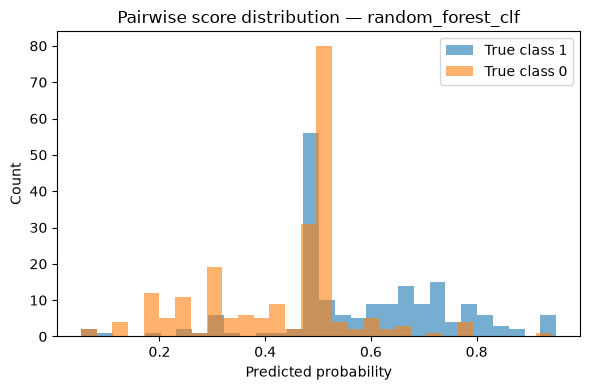

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06E_pairwise\06E_score_hist_random_forest_clf.png


In [18]:
plt.figure(figsize=(6, 4))
plt.hist(y_prob[y_true == 1], bins=30, alpha=0.6, label="True class 1")
plt.hist(y_prob[y_true == 0], bins=30, alpha=0.6, label="True class 0")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title(f"Pairwise score distribution — {BEST_PAIR_MODEL}")
plt.legend()
plt.tight_layout()

out = os.path.join(ARTIFACT_DIR, f"06E_score_hist_{BEST_PAIR_MODEL}.png")
plt.savefig(out, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", out)

In [19]:
# ============================================================
# CORRECTED PAIRWISE METADATA CARD
# ============================================================

card = {
    "notebook": "06E_pairwise_ranking.ipynb",

    "inputs": {
        "X_features": X_FILE,
        "y_target": Y_FILE,
        "groups": GROUP_FILE
    },

    "base_dataset": {
        "n_rows": int(len(X)),
        "n_features": int(X.shape[1]),
        "n_groups": int(groups.nunique())
    },

    "pairwise_dataset": {
        "n_unique_unordered_pairs": int(
            len(X_pair_unique)
        ),
        "n_pair_groups": int(
            pair_groups_unique.nunique()
        ),
        "class_1_pairs": int(
            (y_pair_unique == 1).sum()
        ),
        "class_0_pairs": int(
            (y_pair_unique == 0).sum()
        ),
        "positive_fraction": float(
            y_pair_unique.mean()
        ),
        "reverse_orientation_use":
            "training augmentation only"
    },

    "evaluation": {
        "test_pair_policy":
            "one orientation per unique physical pair",
        "grouping":
            "DOI"
    },

    "best_group_shuffle_model":
        BEST_PAIR_MODEL
}

card_path = os.path.join(
    META_DIR,
    "06E_pairwise_card.json"
)

with open(
    card_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        card,
        f,
        indent=4
    )

print(
    "Saved:",
    card_path
)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\metadata\06E_pairwise_card.json


In [20]:
# ============================================================
# FINAL CORRECTED PAIRWISE SUMMARY
# ============================================================

print(
    "========== 06E CORRECTED PAIRWISE SUMMARY =========="
)

print(
    "Original devices:",
    len(X)
)

print(
    "Original DOI groups:",
    groups.nunique()
)

print(
    "Unique unordered physical pairs:",
    len(X_pair_unique)
)

print(
    "Pairwise DOI groups:",
    pair_groups_unique.nunique()
)

print(
    "Class 0 unique pairs:",
    int((y_pair_unique == 0).sum())
)

print(
    "Class 1 unique pairs:",
    int((y_pair_unique == 1).sum())
)

print(
    "Reverse orientation:",
    "training augmentation only"
)

print(
    "Best pairwise model:",
    BEST_PAIR_MODEL
)

print(
    "\nGROUP SHUFFLE — UNIQUE TEST PAIRS"
)
display(pair_gss_summary)

print(
    "\nGROUP KFOLD — UNIQUE TEST PAIRS"
)
display(pair_gkf_summary)

print(
    "\nPERMUTATION CONTROL"
)
display(pair_perm_summary)

========== 06E CORRECTED PAIRWISE SUMMARY ==========
Original devices: 1835
Original DOI groups: 964
Unique unordered physical pairs: 1590
Pairwise DOI groups: 416
Class 0 unique pairs: 754
Class 1 unique pairs: 836
Reverse orientation: training augmentation only
Best pairwise model: random_forest_clf

GROUP SHUFFLE — UNIQUE TEST PAIRS


,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_unique_pairs_std,test_DOI_mean
2,random_forest_clf,20,0.657132,0.050538,0.677137,0.089237,0.745134,0.048450,332.2,65.762411,84.0
0,hist_gb_clf,20,0.624754,0.056542,0.631489,0.084862,0.710457,0.055683,332.2,65.762411,84.0
1,logreg,20,0.614680,0.048202,0.624031,0.072489,0.698907,0.057639,332.2,65.762411,84.0



GROUP KFOLD — UNIQUE TEST PAIRS


,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_unique_pairs_std,test_DOI_mean
2,random_forest_clf,5,0.676101,0.086521,0.737501,0.071763,0.752702,0.074641,318.0,0.0,83.2
1,logreg,5,0.638994,0.085469,0.650277,0.080144,0.714618,0.074930,318.0,0.0,83.2
0,hist_gb_clf,5,0.628302,0.053846,0.597338,0.081176,0.708327,0.087145,318.0,0.0,83.2



PERMUTATION CONTROL


,model,n_runs,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_DOI_mean
0,hist_gb_clf,10,0.509187,0.045465,0.525064,0.120466,0.520139,0.045527,316.3,84.0
2,random_forest_clf,10,0.510692,0.036960,0.501112,0.102053,0.509907,0.042996,316.3,84.0
1,logreg,10,0.489138,0.029891,0.502415,0.111836,0.487618,0.036550,316.3,84.0


In [21]:
# ============================================================
# COMPACT FINAL NUMBERS FOR MANUSCRIPT TABLE 3
# ============================================================

print("GROUPSHUFFLESPLIT")
display(
    pair_gss_summary[
        [
            "model",
            "accuracy_mean",
            "accuracy_std",
            "f1_mean",
            "f1_std",
            "roc_auc_mean",
            "roc_auc_std",
            "test_unique_pairs_mean",
            "test_unique_pairs_std",
            "test_DOI_mean"
        ]
    ]
)

print("\nGROUPKFOLD")
display(
    pair_gkf_summary[
        [
            "model",
            "accuracy_mean",
            "accuracy_std",
            "f1_mean",
            "f1_std",
            "roc_auc_mean",
            "roc_auc_std",
            "test_unique_pairs_mean",
            "test_unique_pairs_std",
            "test_DOI_mean"
        ]
    ]
)

GROUPSHUFFLESPLIT


,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_unique_pairs_std,test_DOI_mean
2,random_forest_clf,0.657132,0.050538,0.677137,0.089237,0.745134,0.048450,332.2,65.762411,84.0
0,hist_gb_clf,0.624754,0.056542,0.631489,0.084862,0.710457,0.055683,332.2,65.762411,84.0
1,logreg,0.614680,0.048202,0.624031,0.072489,0.698907,0.057639,332.2,65.762411,84.0



GROUPKFOLD


,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,test_unique_pairs_mean,test_unique_pairs_std,test_DOI_mean
2,random_forest_clf,0.676101,0.086521,0.737501,0.071763,0.752702,0.074641,318.0,0.0,83.2
1,logreg,0.638994,0.085469,0.650277,0.080144,0.714618,0.074930,318.0,0.0,83.2
0,hist_gb_clf,0.628302,0.053846,0.597338,0.081176,0.708327,0.087145,318.0,0.0,83.2


In [22]:
# ============================================================
# OOF PREDICTIONS FOR FIGURE 6 AND FIGURE S7
# 1,590 UNIQUE PAIRS — EACH TESTED EXACTLY ONCE
# Reverse orientation used ONLY in training
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import GroupKFold

BEST_PAIR_MODEL = "random_forest_clf"

gkf_plot = GroupKFold(n_splits=5)

pair_oof_prob = np.full(len(X_pair_unique), np.nan)
pair_oof_pred = np.full(len(X_pair_unique), np.nan)

for fold, (train_idx, test_idx) in enumerate(
    gkf_plot.split(
        X_pair_unique,
        y_pair_unique,
        groups=pair_groups_unique
    ),
    start=1
):

    X_train_base = (
        X_pair_unique.iloc[train_idx]
        .reset_index(drop=True)
    )

    y_train_base = (
        y_pair_unique.iloc[train_idx]
        .reset_index(drop=True)
    )

    X_test = X_pair_unique.iloc[test_idx]

    # Training-only reverse augmentation
    X_train_reverse = -X_train_base.copy()
    y_train_reverse = 1 - y_train_base

    X_train = pd.concat(
        [X_train_base, X_train_reverse],
        ignore_index=True
    )

    y_train = pd.concat(
        [y_train_base, y_train_reverse],
        ignore_index=True
    )

    model = clone(models[BEST_PAIR_MODEL])

    model.fit(
        X_train,
        y_train
    )

    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    pair_oof_prob[test_idx] = prob
    pair_oof_pred[test_idx] = pred

assert np.isfinite(pair_oof_prob).all()
assert np.isfinite(pair_oof_pred).all()

pair_oof_pred = pair_oof_pred.astype(int)
pair_oof_true = y_pair_unique.to_numpy()

print("Unique pairs evaluated:", len(pair_oof_true))
print(
    "OOF ROC-AUC:",
    roc_auc_score(pair_oof_true, pair_oof_prob)
)
print(
    "OOF accuracy:",
    accuracy_score(pair_oof_true, pair_oof_pred)
)
print(
    "OOF F1:",
    f1_score(pair_oof_true, pair_oof_pred)
)

Unique pairs evaluated: 1590
OOF ROC-AUC: 0.7462750498140698
OOF accuracy: 0.6761006289308176
OOF F1: 0.7376464595007641


In [23]:
best_gss = pair_gss_summary.sort_values("roc_auc_mean", ascending=False).iloc[0]
best_gkf = pair_gkf_summary.sort_values("roc_auc_mean", ascending=False).iloc[0]
best_perm = pair_perm_summary.sort_values("roc_auc_mean", ascending=False).iloc[0]

print("========== INTERPRETATION DRAFT ==========")
print(
    f"Within-DOI pairwise ranking produced a best mean ROC-AUC of {best_gss['roc_auc_mean']:.3f} "
    f"under repeated grouped holdout (model: {best_gss['model']})."
)
print(
    f"The supporting GroupKFold pairwise result gave a best mean ROC-AUC of {best_gkf['roc_auc_mean']:.3f}."
)
print(
    f"Under permuted-label control, the best observed mean ROC-AUC was {best_perm['roc_auc_mean']:.3f}, "
    f"which should stay near 0.5 if the ranking signal is not driven by leakage."
)

========== INTERPRETATION DRAFT ==========
Within-DOI pairwise ranking produced a best mean ROC-AUC of 0.745 under repeated grouped holdout (model: random_forest_clf).
The supporting GroupKFold pairwise result gave a best mean ROC-AUC of 0.753.
Under permuted-label control, the best observed mean ROC-AUC was 0.520, which should stay near 0.5 if the ranking signal is not driven by leakage.


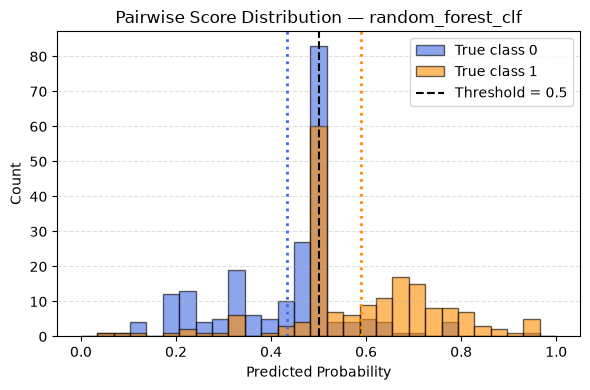

In [24]:
plt.figure(figsize=(6,4))
bins = np.linspace(0, 1, 30)

plt.hist(
    y_prob[y_true == 0],
    bins=bins,
    alpha=0.6,
    color="royalblue",
    edgecolor="black",
    label="True class 0"
)

plt.hist(
    y_prob[y_true == 1],
    bins=bins,
    alpha=0.6,
    color="darkorange",
    edgecolor="black",
    label="True class 1"
)

plt.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold = 0.5")


plt.axvline(np.mean(y_prob[y_true == 0]), color="royalblue", linestyle=":", linewidth=2)
plt.axvline(np.mean(y_prob[y_true == 1]), color="darkorange", linestyle=":", linewidth=2)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title(f"Pairwise Score Distribution — {BEST_PAIR_MODEL}")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="best")

plt.tight_layout()

plt.savefig(out, dpi=600, bbox_inches="tight")
plt.savefig(os.path.join(ARTIFACT_DIR, "roc_auc_heatmap.png"), dpi=600)

plt.show()

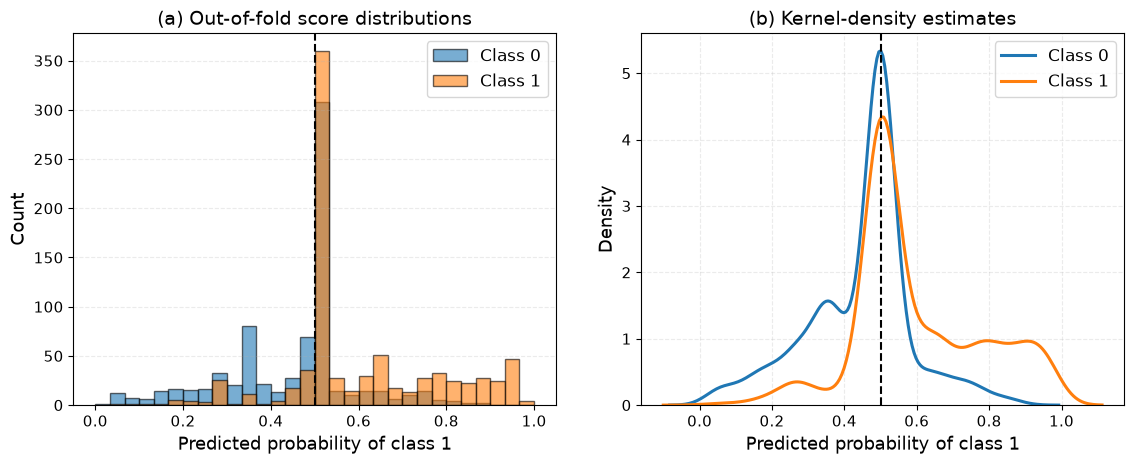

In [25]:
# ============================================================
# FIGURE 6 — PAIRWISE OOF SCORE DISTRIBUTIONS
# ============================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

fig, axes = plt.subplots(
    1, 2,
    figsize=(11.5, 4.8)
)

bins = np.linspace(0, 1, 31)

# -------------------------
# (a) Histogram
# -------------------------
ax = axes[0]

ax.hist(
    pair_oof_prob[pair_oof_true == 0],
    bins=bins,
    alpha=0.60,
    label="Class 0",
    edgecolor="black"
)

ax.hist(
    pair_oof_prob[pair_oof_true == 1],
    bins=bins,
    alpha=0.60,
    label="Class 1",
    edgecolor="black"
)

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    color="black"
)

ax.set_xlabel("Predicted probability of class 1")
ax.set_ylabel("Count")
ax.set_title("(a) Out-of-fold score distributions")
ax.legend(frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.25)


# -------------------------
# (b) KDE
# -------------------------
ax = axes[1]

sns.kdeplot(
    pair_oof_prob[pair_oof_true == 0],
    ax=ax,
    linewidth=2.2,
    label="Class 0"
)

sns.kdeplot(
    pair_oof_prob[pair_oof_true == 1],
    ax=ax,
    linewidth=2.2,
    label="Class 1"
)

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    color="black"
)

ax.set_xlabel("Predicted probability of class 1")
ax.set_ylabel("Density")
ax.set_title("(b) Kernel-density estimates")
ax.legend(frameon=True)
ax.grid(linestyle="--", alpha=0.25)

plt.tight_layout(w_pad=2.5)

plt.savefig(
    os.path.join(
        ARTIFACT_DIR,
        "Fig6_pairwise_unique_pairs.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        ARTIFACT_DIR,
        "Fig6_pairwise_unique_pairs.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

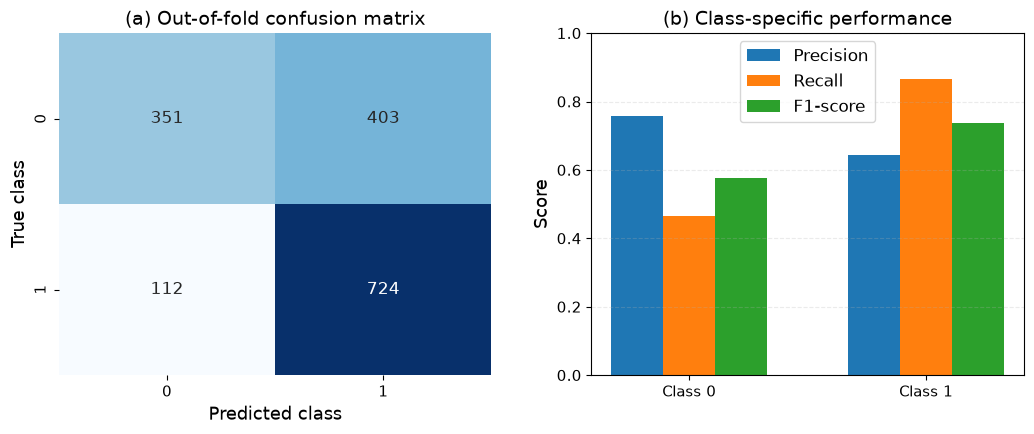

In [26]:
# ============================================================
# FIGURE S7 — UNIQUE-PAIR OOF DIAGNOSTICS
# ============================================================

from sklearn.metrics import precision_recall_fscore_support

cm = confusion_matrix(
    pair_oof_true,
    pair_oof_pred
)

precision, recall, f1, support = (
    precision_recall_fscore_support(
        pair_oof_true,
        pair_oof_pred,
        labels=[0, 1],
        zero_division=0
    )
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(10.5, 4.5)
)

# -------------------------
# (a) Confusion matrix
# -------------------------
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
    annot_kws={"fontsize": 12}
)

axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")
axes[0].set_title("(a) Out-of-fold confusion matrix")

# -------------------------
# (b) Precision / recall / F1
# -------------------------
x = np.arange(2)
width = 0.22

axes[1].bar(
    x - width,
    precision,
    width,
    label="Precision"
)

axes[1].bar(
    x,
    recall,
    width,
    label="Recall"
)

axes[1].bar(
    x + width,
    f1,
    width,
    label="F1-score"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(["Class 0", "Class 1"])
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("Score")
axes[1].set_title("(b) Class-specific performance")
axes[1].legend(frameon=True)
axes[1].grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout(w_pad=2.5)

plt.savefig(
    os.path.join(
        ARTIFACT_DIR,
        "FigS7_pairwise_unique_pairs.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        ARTIFACT_DIR,
        "FigS7_pairwise_unique_pairs.pdf"
    ),
    bbox_inches="tight"
)

plt.show()